# HW10-11 — компьютерное зрение в PyTorch

Выбранные датасеты:
- Часть A: **CIFAR100**
- Часть B: **Pascal VOC**, трек **detection**

В ноутбуке есть базовый, не перегруженный пайплайн:
- классификация CIFAR100 четырьмя конфигами;
- выбор лучшей модели по `val_accuracy`;
- финальная оценка на `test` один раз;
- детекция на Pascal VOC с двумя порогами уверенности;
- визуализация и базовые метрики;
- сохранение `runs.csv`, `best_classifier.pt`, `best_classifier_config.json` и графиков.

In [ ]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms as T
from torchvision.datasets import CIFAR100, VOCDetection
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_bounding_boxes

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
BASE_DIR = Path('./homeworks/HW10-11')
ART_DIR = BASE_DIR / 'artifacts'
FIG_DIR = ART_DIR / 'figures'
ART_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('BASE_DIR:', BASE_DIR.resolve())
print('ART_DIR:', ART_DIR.resolve())
print('FIG_DIR:', FIG_DIR.resolve())

BASE_DIR: /home/jupyter/project/homeworks/HW10-11
ART_DIR: /home/jupyter/project/homeworks/HW10-11/artifacts
FIG_DIR: /home/jupyter/project/homeworks/HW10-11/artifacts/figures


## 1. Часть A — CIFAR100: данные, transforms, sanity-check

Files already downloaded and verified
Files already downloaded and verified
x_batch.shape: torch.Size([8, 3, 32, 32])
y_batch.shape: torch.Size([8])
Classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflo

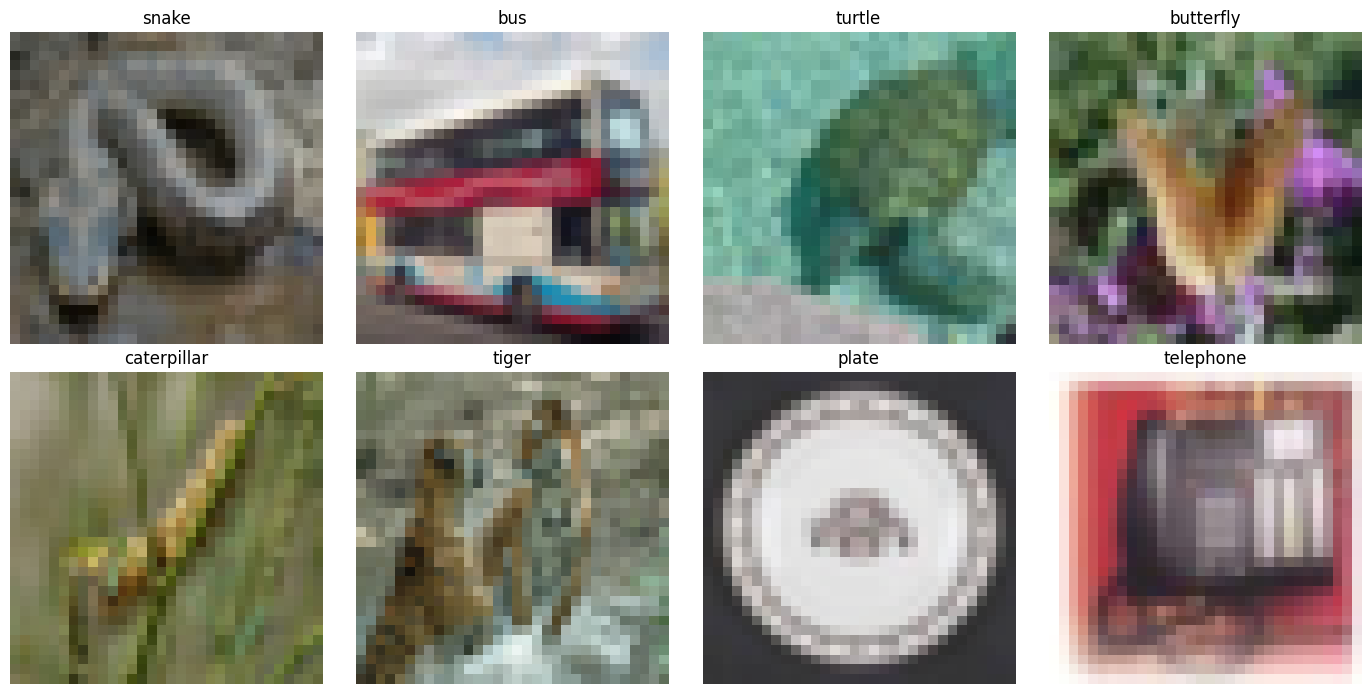

Saved: homeworks/HW10-11/artifacts/figures/augmentations_preview.png


In [ ]:
DATA_ROOT = './data'
NUM_CLASSES = 100
IMAGE_SIZE = 32
BATCH_SIZE_CNN = 64
BATCH_SIZE_RESNET = 32
VAL_FRAC = 0.2

cifar100_mean = (0.5071, 0.4867, 0.4408)
cifar100_std = (0.2675, 0.2565, 0.2761)

cnn_base_train_tf = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(cifar100_mean, cifar100_std),
])

cnn_aug_train_tf = T.Compose([
    T.RandomCrop(IMAGE_SIZE, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    T.ToTensor(),
    T.Normalize(cifar100_mean, cifar100_std),
])

cnn_eval_tf = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(cifar100_mean, cifar100_std),
])

resnet_weights = ResNet18_Weights.DEFAULT
resnet_train_tf = resnet_weights.transforms()
resnet_eval_tf = resnet_weights.transforms()

preview_aug_tf = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
])

class IndexedDataset(Dataset):
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.base_dataset[self.indices[idx]]

def make_split_indices(n, val_frac=0.2, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)
    val_size = int(n * val_frac)
    return indices[val_size:], indices[:val_size]

def build_cifar100_datasets(train_tf, eval_tf, seed=42):
    base_train = CIFAR100(root=DATA_ROOT, train=True, download=True, transform=None)
    train_idx, val_idx = make_split_indices(len(base_train), val_frac=VAL_FRAC, seed=seed)
    train_ds = IndexedDataset(CIFAR100(root=DATA_ROOT, train=True, download=False, transform=train_tf), train_idx)
    val_ds = IndexedDataset(CIFAR100(root=DATA_ROOT, train=True, download=False, transform=eval_tf), val_idx)
    test_ds = CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_tf)
    return train_ds, val_ds, test_ds

def get_loader(ds, batch_size, shuffle=False, num_workers=0):
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

train_ds_cnn_base, val_ds_cnn_base, test_ds_cnn_base = build_cifar100_datasets(cnn_base_train_tf, cnn_eval_tf, seed=SEED)
train_loader_preview = get_loader(train_ds_cnn_base, batch_size=8, shuffle=True)
x_batch, y_batch = next(iter(train_loader_preview))
print('x_batch.shape:', x_batch.shape)
print('y_batch.shape:', y_batch.shape)

classes_cifar100 = CIFAR100(root=DATA_ROOT, train=True, download=False).classes
print('Classes:', classes_cifar100)

def denormalize_cifar100(x):
    mean = torch.tensor(cifar100_mean).view(3, 1, 1)
    std = torch.tensor(cifar100_std).view(3, 1, 1)
    return torch.clamp(x * std + mean, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, label in zip(axes.flatten(), x_batch, y_batch):
    img_show = denormalize_cifar100(img).permute(1, 2, 0).numpy()
    ax.imshow(img_show)
    ax.set_title(classes_cifar100[int(label)])
    ax.axis('off')
plt.tight_layout()
preview_path = FIG_DIR / 'augmentations_preview.png'
plt.savefig(preview_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', preview_path)

## 2. Часть A — модели, обучение и сравнение

Files already downloaded and verified
Files already downloaded and verified


[C1] train 1/5: 100%|█████████▉| 623/625 [00:24<00:00, 28.62it/s, acc=0.1294, loss=3.7247]
                                                                                          
[C1] epochs:  20%|██        | 1/5 [00:29<01:56, 29.17s/it, best=0.2056, train_acc=0.1294, train_loss=3.7247, val_acc=0.2056, val_loss=3.2678]

[C1] epoch 01/5 train_loss=3.7247 train_acc=0.1294 val_loss=3.2678 val_acc=0.2056



[C1] train 2/5: 100%|█████████▉| 624/625 [00:20<00:00, 29.40it/s, acc=0.2306, loss=3.1266]
                                                                                          
[C1] epochs:  40%|████      | 2/5 [00:54<01:21, 27.09s/it, best=0.2489, train_acc=0.2306, train_loss=3.1266, val_acc=0.2489, val_loss=3.0432]

[C1] epoch 02/5 train_loss=3.1266 train_acc=0.2306 val_loss=3.0432 val_acc=0.2489


...

[C4] epoch 02/4 train_loss=1.0326 train_acc=0.7240 val_loss=1.1011 val_acc=0.6835



[C4] train 3/4: 100%|██████████| 1250/1250 [01:37<00:00, 12.99it/s, acc=0.8470, loss=0.5960]
                                                                                            
[C4] epochs:  75%|███████▌  | 3/4 [05:59<01:59, 119.77s/it, best=0.6950, train_acc=0.8470, train_loss=0.5960, val_acc=0.6950, val_loss=1.0752]

[C4] epoch 03/4 train_loss=0.5960 train_acc=0.8470 val_loss=1.0752 val_acc=0.6950



[C4] train 4/4: 100%|██████████| 1250/1250 [01:37<00:00, 13.09it/s, acc=0.9367, loss=0.2927]
                                                                                            
[C4] epochs: 100%|██████████| 4/4 [07:58<00:00, 119.75s/it, best=0.6950, train_acc=0.9367, train_loss=0.2927, val_acc=0.6861, val_loss=1.1085]


[C4] epoch 04/4 train_loss=0.2927 train_acc=0.9367 val_loss=1.1085 val_acc=0.6861


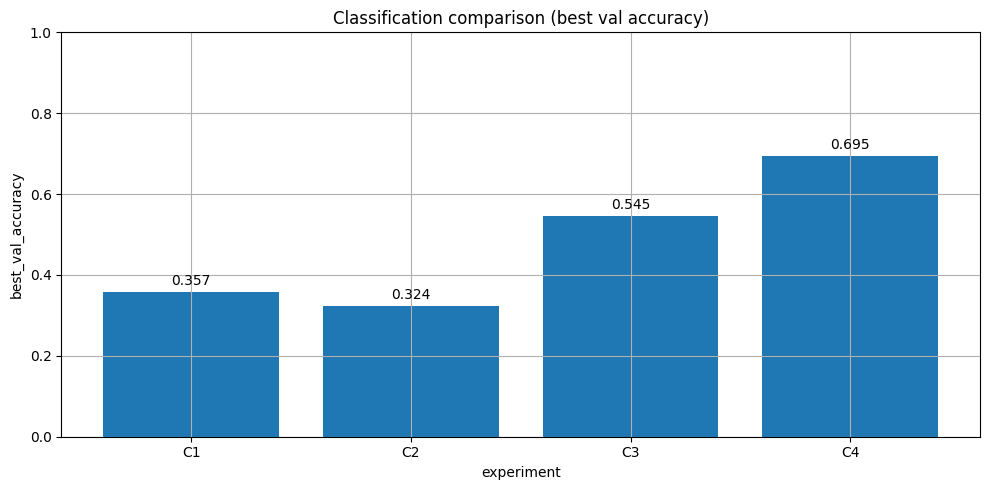

Saved: homeworks/HW10-11/artifacts/figures/classification_compare.png


{'experiment_id': 'C4',
 'task': 'classification',
 'dataset': 'CIFAR100',
 'seed': 42,
 'model_summary': 'ResNet',
 'optimizer': 'Adam',
 'lr': 0.0001,
 'epochs_trained': 4,
 'best_val_accuracy': 0.695,
 'test_accuracy': None,
 'precision': None,
 'recall': None,
 'mean_iou': None,
 'notes': 'ResNet18 pretrained, layer4 + fc trainable',
 'best_epoch': 3}

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def train_one_epoch(model, loader, optimizer, criterion, device, desc='Train'):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    pbar = tqdm(loader, desc=desc, leave=False)
    for xb, yb in pbar:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_count += batch_size
        pbar.set_postfix(loss=f'{total_loss / total_count:.4f}', acc=f'{total_correct / total_count:.4f}')
    return total_loss / total_count, total_correct / total_count

@torch.no_grad()
def evaluate(model, loader, criterion, device, desc='Val'):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    pbar = tqdm(loader, desc=desc, leave=False)
    for xb, yb in pbar:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_count += batch_size
        pbar.set_postfix(loss=f'{total_loss / total_count:.4f}', acc=f'{total_correct / total_count:.4f}')
    return total_loss / total_count, total_correct / total_count

def fit_classifier(experiment_id, model, train_loader, val_loader, epochs, lr, optimizer_name='Adam', weight_decay=0.0, notes=''):
    criterion = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    if optimizer_name.lower() == 'sgd':
        optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

    model = model.to(device)
    best_state = None
    best_val_acc = -1.0
    best_epoch = -1
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    epoch_bar = tqdm(range(1, epochs + 1), desc=f'[{experiment_id}] epochs')
    for epoch in epoch_bar:
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, desc=f'[{experiment_id}] train {epoch}/{epochs}')
        val_loss, val_acc = evaluate(model, val_loader, criterion, device, desc=f'[{experiment_id}] val   {epoch}/{epochs}')
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epoch_bar.set_postfix(train_loss=f'{train_loss:.4f}', train_acc=f'{train_acc:.4f}', val_loss=f'{val_loss:.4f}', val_acc=f'{val_acc:.4f}', best=f'{best_val_acc:.4f}')
        print(f'[{experiment_id}] epoch {epoch:02d}/{epochs} train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

    result = {
        'experiment_id': experiment_id,
        'task': 'classification',
        'dataset': 'CIFAR100',
        'seed': SEED,
        'model_summary': model.__class__.__name__,
        'optimizer': optimizer_name,
        'lr': lr,
        'epochs_trained': epochs,
        'best_val_accuracy': best_val_acc,
        'test_accuracy': None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': notes,
        'best_epoch': best_epoch,
    }
    return model, best_state, history, result

def make_resnet18(num_classes=100, finetune=False):
    model = resnet18(weights=resnet_weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    if not finetune:
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True
    else:
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True
    return model

def plot_history(history, title, save_path):
    epochs = np.arange(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['val_loss'], label='val')
    axes[0].set_title(f'{title} — loss')
    axes[0].set_xlabel('epoch')
    axes[0].legend()
    axes[1].plot(epochs, history['train_acc'], label='train')
    axes[1].plot(epochs, history['val_acc'], label='val')
    axes[1].set_title(f'{title} — accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path)

experiments = []

train_ds_c1, val_ds_c1, test_ds_c1 = build_cifar100_datasets(cnn_base_train_tf, cnn_eval_tf, seed=SEED)
train_loader_c1 = get_loader(train_ds_c1, BATCH_SIZE_CNN, shuffle=True)
val_loader_c1 = get_loader(val_ds_c1, BATCH_SIZE_CNN, shuffle=False)
test_loader_c1 = get_loader(test_ds_c1, BATCH_SIZE_CNN, shuffle=False)
model_c1 = SimpleCNN(NUM_CLASSES)
model_c1, state_c1, hist_c1, res_c1 = fit_classifier('C1', model_c1, train_loader_c1, val_loader_c1, epochs=5, lr=1e-3, optimizer_name='Adam', notes='simple CNN without augmentations')
experiments.append((res_c1, hist_c1))

train_ds_c2, val_ds_c2, test_ds_c2 = build_cifar100_datasets(cnn_aug_train_tf, cnn_eval_tf, seed=SEED)
train_loader_c2 = get_loader(train_ds_c2, BATCH_SIZE_CNN, shuffle=True)
val_loader_c2 = get_loader(val_ds_c2, BATCH_SIZE_CNN, shuffle=False)
test_loader_c2 = get_loader(test_ds_c2, BATCH_SIZE_CNN, shuffle=False)
model_c2 = SimpleCNN(NUM_CLASSES)
model_c2, state_c2, hist_c2, res_c2 = fit_classifier('C2', model_c2, train_loader_c2, val_loader_c2, epochs=5, lr=1e-3, optimizer_name='Adam', notes='same CNN with augmentations')
experiments.append((res_c2, hist_c2))

train_ds_c3, val_ds_c3, test_ds_c3 = build_cifar100_datasets(resnet_train_tf, resnet_eval_tf, seed=SEED)
train_loader_c3 = get_loader(train_ds_c3, BATCH_SIZE_RESNET, shuffle=True)
val_loader_c3 = get_loader(val_ds_c3, BATCH_SIZE_RESNET, shuffle=False)
test_loader_c3 = get_loader(test_ds_c3, BATCH_SIZE_RESNET, shuffle=False)
model_c3 = make_resnet18(NUM_CLASSES, finetune=False)
model_c3, state_c3, hist_c3, res_c3 = fit_classifier('C3', model_c3, train_loader_c3, val_loader_c3, epochs=4, lr=1e-3, optimizer_name='Adam', notes='ResNet18 pretrained, frozen backbone, train head only')
experiments.append((res_c3, hist_c3))

train_ds_c4, val_ds_c4, test_ds_c4 = build_cifar100_datasets(resnet_train_tf, resnet_eval_tf, seed=SEED)
train_loader_c4 = get_loader(train_ds_c4, BATCH_SIZE_RESNET, shuffle=True)
val_loader_c4 = get_loader(val_ds_c4, BATCH_SIZE_RESNET, shuffle=False)
test_loader_c4 = get_loader(test_ds_c4, BATCH_SIZE_RESNET, shuffle=False)
model_c4 = make_resnet18(NUM_CLASSES, finetune=True)
model_c4, state_c4, hist_c4, res_c4 = fit_classifier('C4', model_c4, train_loader_c4, val_loader_c4, epochs=4, lr=1e-4, optimizer_name='Adam', notes='ResNet18 pretrained, layer4 + fc trainable')
experiments.append((res_c4, hist_c4))

results = [r for r, _ in experiments]
compare_ids = [r['experiment_id'] for r in results]
compare_vals = [r['best_val_accuracy'] for r in results]
plt.figure(figsize=(10, 5))
bars = plt.bar(compare_ids, compare_vals)
plt.title('Classification comparison (best val accuracy)')
plt.xlabel('experiment')
plt.ylabel('best_val_accuracy')
plt.ylim(0, 1)
for bar, val in zip(bars, compare_vals):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f'{val:.3f}', ha='center', va='bottom')
compare_path = FIG_DIR / 'classification_compare.png'
plt.tight_layout()
plt.savefig(compare_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', compare_path)

best_result = max(results, key=lambda x: x['best_val_accuracy'])
best_experiment_id = best_result['experiment_id']
best_result

In [ ]:
if best_experiment_id == 'C1':
    best_model = SimpleCNN(NUM_CLASSES)
    best_model.load_state_dict(state_c1)
    best_state = state_c1
    best_history = hist_c1
    best_loader = test_loader_c1
    best_config = {
        'experiment_id': 'C1',
        'dataset': 'CIFAR100',
        'architecture': 'SimpleCNN',
        'train_transform': 'cnn_base_train_tf',
        'eval_transform': 'cnn_eval_tf',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs': 5,
        'seed': SEED,
    }
elif best_experiment_id == 'C2':
    best_model = SimpleCNN(NUM_CLASSES)
    best_model.load_state_dict(state_c2)
    best_state = state_c2
    best_history = hist_c2
    best_loader = test_loader_c2
    best_config = {
        'experiment_id': 'C2',
        'dataset': 'CIFAR100',
        'architecture': 'SimpleCNN',
        'train_transform': 'cnn_aug_train_tf',
        'eval_transform': 'cnn_eval_tf',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs': 5,
        'seed': SEED,
    }
elif best_experiment_id == 'C3':
    best_model = make_resnet18(NUM_CLASSES, finetune=False)
    best_model.load_state_dict(state_c3)
    best_state = state_c3
    best_history = hist_c3
    best_loader = test_loader_c3
    best_config = {
        'experiment_id': 'C3',
        'dataset': 'CIFAR100',
        'architecture': 'ResNet18',
        'train_transform': 'resnet_train_tf',
        'eval_transform': 'resnet_eval_tf',
        'frozen_backbone': True,
        'trainable_parts': ['fc'],
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs': 4,
        'seed': SEED,
    }
else:
    best_model = make_resnet18(NUM_CLASSES, finetune=True)
    best_model.load_state_dict(state_c4)
    best_state = state_c4
    best_history = hist_c4
    best_loader = test_loader_c4
    best_config = {
        'experiment_id': 'C4',
        'dataset': 'CIFAR100',
        'architecture': 'ResNet18',
        'train_transform': 'resnet_train_tf',
        'eval_transform': 'resnet_eval_tf',
        'frozen_backbone': True,
        'trainable_parts': ['layer4', 'fc'],
        'optimizer': 'Adam',
        'lr': 1e-4,
        'epochs': 4,
        'seed': SEED,
    }

best_model = best_model.to(device)
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, best_loader, criterion, device)
best_result['test_accuracy'] = test_acc
best_result['notes'] += ' | selected as best model'
best_result, test_acc

({'experiment_id': 'C4',
  'task': 'classification',
  'dataset': 'CIFAR100',
  'seed': 42,
  'model_summary': 'ResNet',
  'optimizer': 'Adam',
  'lr': 0.0001,
  'epochs_trained': 4,
  'best_val_accuracy': 0.695,
  'test_accuracy': 0.6923,
  'precision': None,
  'recall': None,
  'mean_iou': None,
  'notes': 'ResNet18 pretrained, layer4 + fc trainable | selected as best model',
  'best_epoch': 3},
 0.6923)

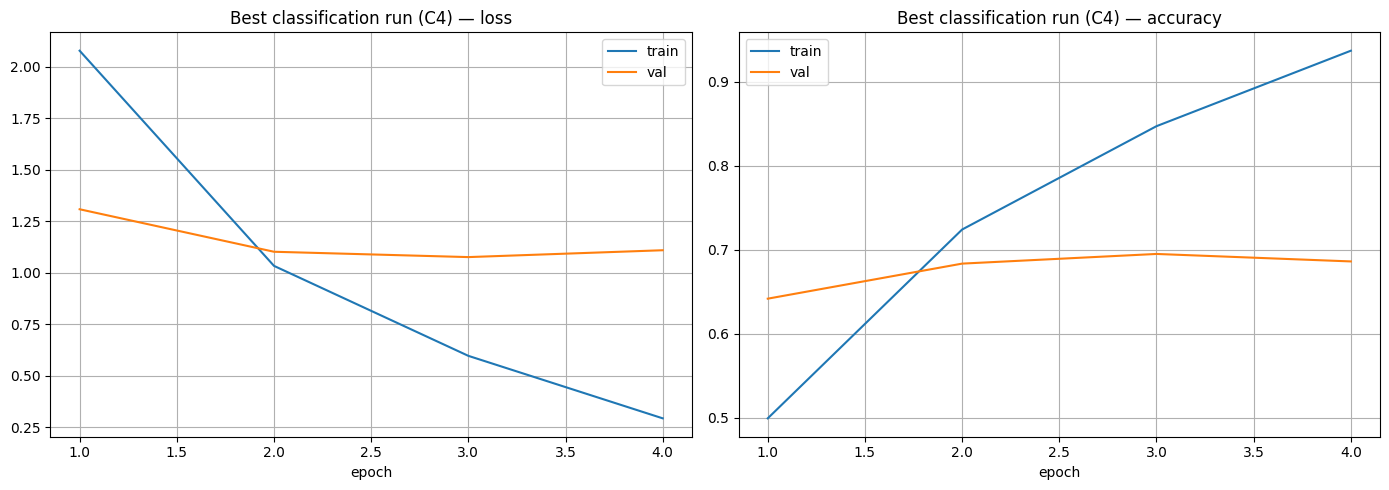

Saved: homeworks/HW10-11/artifacts/figures/classification_curves_best.png


In [ ]:
torch.save(best_state, ART_DIR / 'best_classifier.pt')
with open(ART_DIR / 'best_classifier_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)
plot_history(best_history, f'Best classification run ({best_experiment_id})', FIG_DIR / 'classification_curves_best.png')

In [ ]:
runs_df = pd.DataFrame(results)
runs_df

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes,best_epoch
0,C1,classification,CIFAR100,42,SimpleCNN,Adam,0.0010,5,0.3567,NaN,None,None,None,simple CNN without augmentations,5
1,C2,classification,CIFAR100,42,SimpleCNN,Adam,0.0010,5,0.3243,NaN,None,None,None,same CNN with augmentations,5
2,C3,classification,CIFAR100,42,ResNet,Adam,0.0010,4,0.5447,NaN,None,None,None,"ResNet18 pretrained, frozen backbone, train he...",4
3,C4,classification,CIFAR100,42,ResNet,Adam,0.0001,4,0.6950,0.6923,None,None,None,"ResNet18 pretrained, layer4 + fc trainable | s...",3


## 3. Часть B — Pascal VOC detection

In [ ]:
VOC_ROOT = './data'
detection_weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
det_model = fasterrcnn_resnet50_fpn(weights=detection_weights).to(device)
det_model.eval()

voc_ds = VOCDetection(root=VOC_ROOT, year='2007', image_set='val', download=True)
len(voc_ds)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /tmp/xdg_cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 115MB/s]  


100%|██████████| 460032000/460032000 [00:11<00:00, 41547212.02it/s]


Extracting ./data/VOCtrainval_06-Nov-2007.tar to ./data


2510

Using downloaded and verified file: ./data/VOCtrainval_06-Nov-2007.tar
Extracting ./data/VOCtrainval_06-Nov-2007.tar to ./data
Dataset size: 2510
image tensor shape: torch.Size([3, 375, 500])
boxes: torch.Size([5, 4])
labels: torch.Size([5])


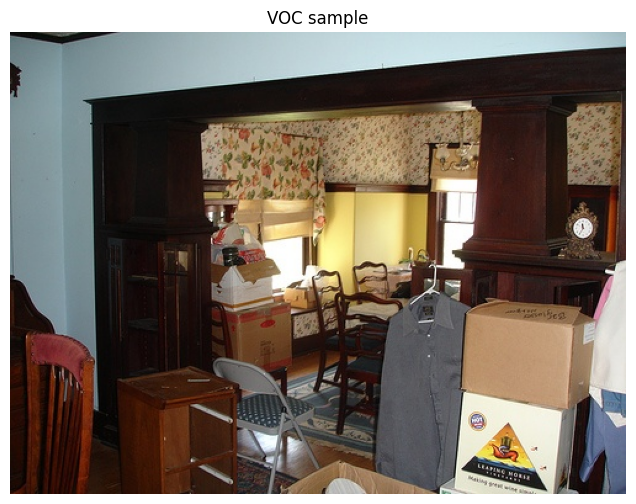

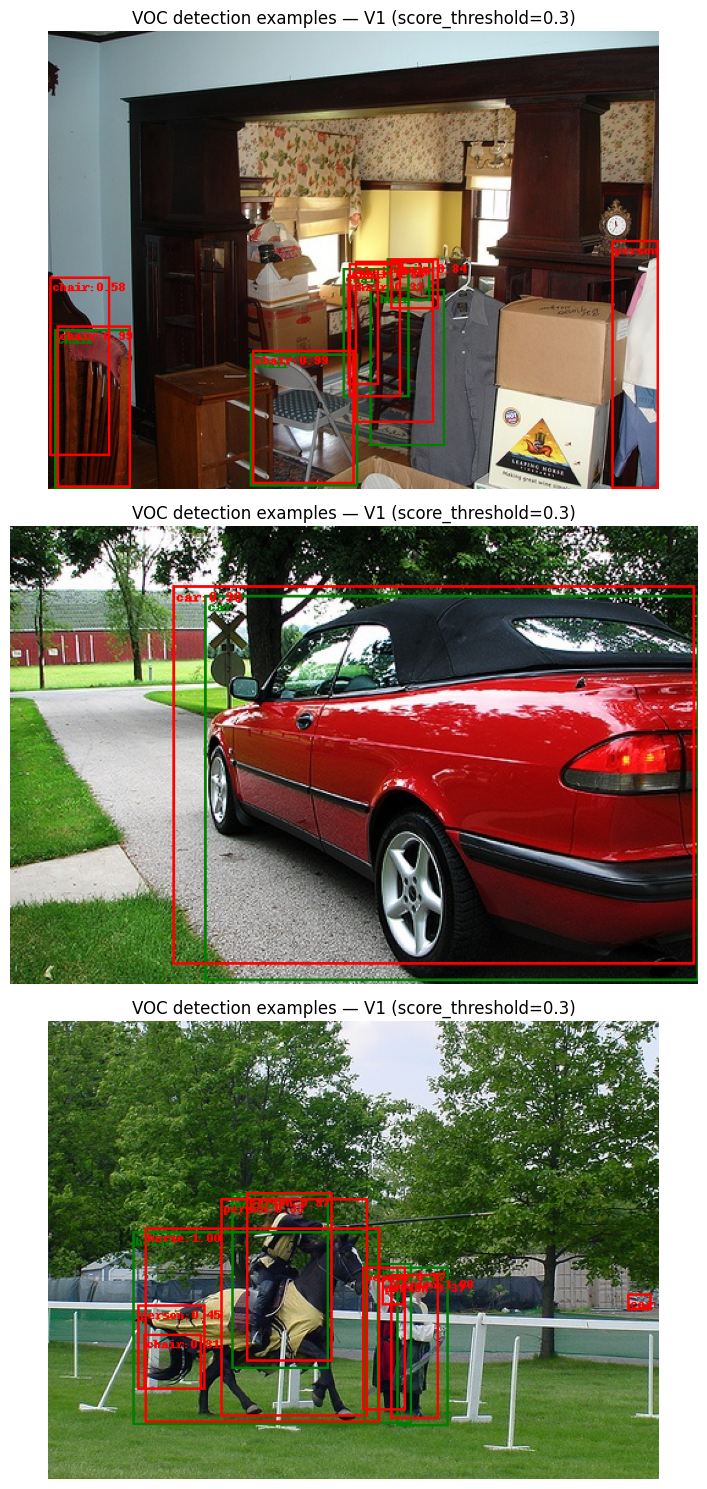

Saved: figures/detection_examples.png


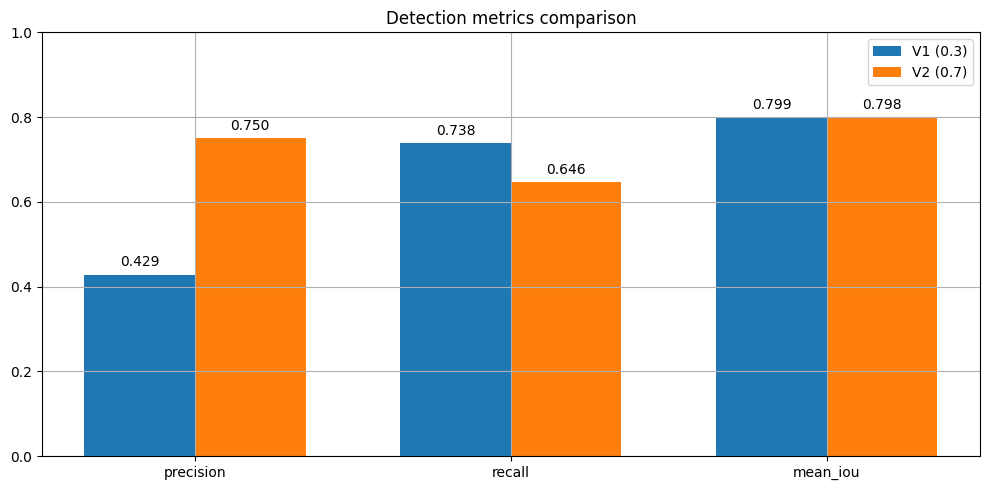

Saved: figures/detection_metrics.png


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,V1,detection,Pascal VOC 2007 val,42,FasterRCNN_ResNet50_FPN,,,0,,,0.428571,0.738462,0.798659,score_threshold=0.3
1,V2,detection,Pascal VOC 2007 val,42,FasterRCNN_ResNet50_FPN,,,0,,,0.750000,0.646154,0.798112,score_threshold=0.7


In [21]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_bounding_boxes
from torchvision.datasets import VOCDetection
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Настройки
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Директории
FIG_DIR = Path('./figures')
ART_DIR = Path('./artifacts')
FIG_DIR.mkdir(exist_ok=True, parents=True)
ART_DIR.mkdir(exist_ok=True, parents=True)

VOC_ROOT = './data'

# VOC классы (0 = background)
VOC_CLASSES = [
    'background',
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable',
    'dog', 'horse', 'motorbike', 'person', 'pottedplant',
    'sheep', 'sofa', 'train', 'tvmonitor'
]
VOC_CLASS_TO_IDX = {c: i for i, c in enumerate(VOC_CLASSES)}

# COCO классы (нужны для маппинга)
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# Маппинг COCO -> VOC (по названиям классов)
COCO_TO_VOC = {}
for coco_idx, coco_name in enumerate(COCO_CLASSES):
    if coco_name in VOC_CLASS_TO_IDX:
        COCO_TO_VOC[coco_idx] = VOC_CLASS_TO_IDX[coco_name]

MAX_VOC_IMAGES = 20

def voc_annotation_to_target(annotation):
    objs = annotation['annotation'].get('object', [])
    if isinstance(objs, dict):
        objs = [objs]

    boxes, labels, difficult = [], [], []
    for obj in objs:
        cls_name = obj['name']
        if cls_name not in VOC_CLASS_TO_IDX:
            continue
        bbox = obj['bndbox']
        boxes.append([
            float(bbox['xmin']), float(bbox['ymin']),
            float(bbox['xmax']), float(bbox['ymax'])
        ])
        labels.append(VOC_CLASS_TO_IDX[cls_name])
        difficult.append(int(obj.get('difficult', 0)))

    if len(boxes) == 0:
        boxes = torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.zeros((0,), dtype=torch.int64)
        difficult = torch.zeros((0,), dtype=torch.int64)
    else:
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        difficult = torch.tensor(difficult, dtype=torch.int64)

    return {'boxes': boxes, 'labels': labels, 'difficult': difficult}

def box_iou(box1, box2):
    if box2.numel() == 0:
        return torch.zeros((0,), dtype=torch.float32)
    x11, y11, x12, y12 = box1
    x21, y21, x22, y22 = box2[:, 0], box2[:, 1], box2[:, 2], box2[:, 3]
    inter_x1 = torch.maximum(x11, x21)
    inter_y1 = torch.maximum(y11, y21)
    inter_x2 = torch.minimum(x12, x22)
    inter_y2 = torch.minimum(y12, y22)
    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter_area = inter_w * inter_h
    area1 = torch.clamp(x12 - x11, min=0) * torch.clamp(y12 - y11, min=0)
    area2 = torch.clamp(x22 - x21, min=0) * torch.clamp(y22 - y21, min=0)
    union = area1 + area2 - inter_area
    return inter_area / torch.clamp(union, min=1e-6)

def greedy_match_predictions(pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels, iou_thr=0.5):
    if gt_boxes.numel() == 0:
        return 0, len(pred_boxes), 0, None

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    pred_labels = pred_labels[order]
    pred_scores = pred_scores[order]

    matched_gt = set()
    tp = 0
    fp = 0
    ious = []

    for pbox, plabel in zip(pred_boxes, pred_labels):
        candidate_idxs = [i for i in range(len(gt_boxes)) if i not in matched_gt and int(gt_labels[i]) == int(plabel)]
        if len(candidate_idxs) == 0:
            fp += 1
            continue
        cand_boxes = gt_boxes[candidate_idxs]
        ious_to_cands = box_iou(pbox, cand_boxes)
        best_iou, best_local = torch.max(ious_to_cands, dim=0)
        if float(best_iou) >= iou_thr:
            tp += 1
            matched_gt.add(candidate_idxs[int(best_local)])
            ious.append(float(best_iou))
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)
    mean_iou = float(np.mean(ious)) if len(ious) > 0 else None
    return tp, fp, fn, mean_iou

@torch.no_grad()
def run_detection_eval(model, dataset, score_threshold=0.3, max_images=20, visualize_n=4):
    model.eval()
    all_tp, all_fp, all_fn = 0, 0, 0
    all_ious = []
    vis_samples = []
    total = min(max_images, len(dataset))
    pbar = tqdm(range(total), desc=f'Detection eval @ thr={score_threshold}', leave=False)
    for idx in pbar:
        img_pil, ann = dataset[idx]
        gt = voc_annotation_to_target(ann)
        img_tensor = T.ToTensor()(img_pil).to(device)
        outputs = model([img_tensor])[0]
        keep = outputs['scores'] >= score_threshold
        pred_boxes = outputs['boxes'][keep].detach().cpu()
        pred_labels_coco = outputs['labels'][keep].detach().cpu()
        pred_scores = outputs['scores'][keep].detach().cpu()
        
        # Конвертируем COCO метки в VOC метлы
        pred_labels = torch.tensor([COCO_TO_VOC.get(int(lbl), -1) for lbl in pred_labels_coco], dtype=torch.int64)
        
        # Фильтруем предсказания без маппинга (остаются только -1)
        valid_mask = pred_labels >= 0
        pred_boxes = pred_boxes[valid_mask]
        pred_labels = pred_labels[valid_mask]
        pred_scores = pred_scores[valid_mask]
        
        tp, fp, fn, miou = greedy_match_predictions(pred_boxes, pred_labels, pred_scores, gt['boxes'], gt['labels'], iou_thr=0.5)
        all_tp += tp
        all_fp += fp
        all_fn += fn
        if miou is not None:
            all_ious.append(miou)
        if len(vis_samples) < visualize_n:
            vis_samples.append((img_pil, pred_boxes, pred_labels, pred_scores, gt))
        pbar.set_postfix(tp=all_tp, fp=all_fp, fn=all_fn)
    precision = all_tp / max(all_tp + all_fp, 1)
    recall = all_tp / max(all_tp + all_fn, 1)
    mean_iou = float(np.mean(all_ious)) if len(all_ious) > 0 else None
    metrics = {'precision': precision, 'recall': recall, 'mean_iou': mean_iou, 'tp': all_tp, 'fp': all_fp, 'fn': all_fn}
    return metrics, vis_samples

def draw_detection_examples(vis_samples, title, save_path):
    fig, axes = plt.subplots(len(vis_samples), 1, figsize=(12, 5 * len(vis_samples)))
    if len(vis_samples) == 1:
        axes = [axes]
    for ax, (img_pil, pred_boxes, pred_labels, pred_scores, gt) in zip(axes, vis_samples):
        img = T.ToTensor()(img_pil)
        gt_text = [VOC_CLASSES[int(x)] for x in gt['labels']] if len(gt['labels']) else []
        # Теперь pred_labels уже в формате VOC
        pred_text = [f"{VOC_CLASSES[int(lbl)]}:{float(score):.2f}" for lbl, score in zip(pred_labels, pred_scores)]
        drawn = draw_bounding_boxes((img * 255).to(torch.uint8), gt['boxes'], labels=gt_text, colors='green', width=2)
        if len(pred_boxes) > 0:
            drawn = draw_bounding_boxes(drawn, pred_boxes, labels=pred_text, colors='red', width=2)
        ax.imshow(drawn.permute(1, 2, 0))
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path)

# Загрузка модели и данных
detection_weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
det_model = fasterrcnn_resnet50_fpn(weights=detection_weights).to(device)
det_model.eval()

voc_ds = VOCDetection(root=VOC_ROOT, year='2007', image_set='val', download=True)
print(f"Dataset size: {len(voc_ds)}")

# Тестовый вывод
pil_img, img_tensor, target = (lambda idx: (voc_ds[idx][0], T.ToTensor()(voc_ds[idx][0]), voc_annotation_to_target(voc_ds[idx][1])))(0)
print('image tensor shape:', img_tensor.shape)
print('boxes:', target['boxes'].shape)
print('labels:', target['labels'].shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(pil_img)
ax.set_title('VOC sample')
ax.axis('off')
plt.show()

# Оценка детекции
metrics_v1, vis_v1 = run_detection_eval(det_model, voc_ds, score_threshold=0.3, max_images=MAX_VOC_IMAGES, visualize_n=3)
draw_detection_examples(vis_v1, 'VOC detection examples — V1 (score_threshold=0.3)', str(FIG_DIR / 'detection_examples.png'))
metrics_v2, vis_v2 = run_detection_eval(det_model, voc_ds, score_threshold=0.7, max_images=MAX_VOC_IMAGES, visualize_n=3)

# Создание DataFrame
det_metrics = [
    {'experiment_id': 'V1', 'task': 'detection', 'dataset': 'Pascal VOC 2007 val', 'seed': SEED,
     'model_summary': 'FasterRCNN_ResNet50_FPN', 'optimizer': '', 'lr': '', 'epochs_trained': 0,
     'best_val_accuracy': '', 'test_accuracy': '', 'precision': metrics_v1['precision'], 'recall': metrics_v1['recall'],
     'mean_iou': metrics_v1['mean_iou'], 'notes': 'score_threshold=0.3'},
    {'experiment_id': 'V2', 'task': 'detection', 'dataset': 'Pascal VOC 2007 val', 'seed': SEED,
     'model_summary': 'FasterRCNN_ResNet50_FPN', 'optimizer': '', 'lr': '', 'epochs_trained': 0,
     'best_val_accuracy': '', 'test_accuracy': '', 'precision': metrics_v2['precision'], 'recall': metrics_v2['recall'],
     'mean_iou': metrics_v2['mean_iou'], 'notes': 'score_threshold=0.7'},
]
det_df = pd.DataFrame(det_metrics)

# Визуализация метрик
labels = ['precision', 'recall', 'mean_iou']
x = np.arange(len(labels))
width = 0.35
v1_vals = [metrics_v1['precision'], metrics_v1['recall'], metrics_v1['mean_iou'] if metrics_v1['mean_iou'] is not None else 0.0]
v2_vals = [metrics_v2['precision'], metrics_v2['recall'], metrics_v2['mean_iou'] if metrics_v2['mean_iou'] is not None else 0.0]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, v1_vals, width, label='V1 (0.3)')
ax.bar(x + width / 2, v2_vals, width, label='V2 (0.7)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title('Detection metrics comparison')
ax.legend()
for i, val in enumerate(v1_vals):
    ax.text(i - width / 2, val + 0.02, f'{val:.3f}', ha='center')
for i, val in enumerate(v2_vals):
    ax.text(i + width / 2, val + 0.02, f'{val:.3f}', ha='center')
metrics_path = FIG_DIR / 'detection_metrics.png'
plt.tight_layout()
plt.savefig(metrics_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', metrics_path)

# Сохранение результатов
# all_runs = pd.concat([runs_df, det_df], ignore_index=True)  # раскомментируйте если есть runs_df
# all_runs.to_csv(ART_DIR / 'runs.csv', index=False)
# all_runs
det_df
